# Archivist Baseline Model Implementation

This notebook evaluates a lightweight, fully local Retrieval-Augmented Generation (RAG) pipeline using educational content from OpenStax *Principles of Data Science*, section 1.3. It compares the same small Ollama language model with and without retrieved textbook context.

**Research objective:** Determine whether a small local language model produces more correct and grounded answers when supplied with retrieved textbook context.

This is a small initial baseline, not the full Archivist application. Model execution is opt-in, results are saved incrementally, and correctness is scored manually rather than inferred from string matching.

## 1. Environment and Dependencies

Required packages: `ollama`, `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `psutil`, and `jupyter`. This notebook does not install packages automatically. From a terminal in the project directory, run:

```bash
uv add ollama pandas numpy scikit-learn matplotlib psutil jupyter
ollama pull qwen3:0.6b
ollama pull nomic-embed-text
```

Start Ollama if it is not already running. The expected endpoint is `http://localhost:11434`.

In [1]:
from __future__ import annotations

import hashlib
import json
import random
import re
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display
from ollama import Client, ResponseError
from sklearn.metrics.pairwise import cosine_similarity

## 2. Imports and Configuration

Change model names, paths, or retrieval settings in this single configuration cell. All paths are relative to the repository root.

In [2]:
TEXT_PATH = "data/openstax_section_1_3.txt"
QUESTIONS_PATH = "data/openstax_questions.csv"
RESULTS_PATH = "results/baseline_results.csv"
OLLAMA_HOST = "http://localhost:11434"
CHAT_MODEL = "qwen3:0.6b"
EMBEDDING_MODEL = "nomic-embed-text:latest"
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
TOP_K = 3
TEMPERATURE = 0.0
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
Path(RESULTS_PATH).parent.mkdir(parents=True, exist_ok=True)

## 3. Ollama Health Check

The check below tests the configured host and, when possible, verifies both model names. Ordinary setup failures produce concise instructions rather than a large stack trace. The experiment cell later uses this result to stop gracefully.

In [3]:
def _model_name(model: Any) -> str:
    """Extract a model name from Ollama response objects across client versions."""
    if isinstance(model, dict):
        return str(model.get("model") or model.get("name") or "")
    return str(getattr(model, "model", None) or getattr(model, "name", ""))


def check_ollama_health() -> bool:
    """Return True when Ollama is reachable and configured models are installed."""
    try:
        response = Client(host=OLLAMA_HOST, timeout=5.0).list()
        models = response.get("models", []) if isinstance(response, dict) else response.models
        available = {_model_name(model) for model in models}
        missing = [name for name in (CHAT_MODEL, EMBEDDING_MODEL) if name not in available]
        if missing:
            print("Ollama is reachable, but required model(s) are missing:")
            for name in missing:
                print(f"  ollama pull {name}")
            return False
        print(f"Ollama is healthy at {OLLAMA_HOST}. Configured models are available.")
        return True
    except Exception as exc:
        print(f"Ollama is unavailable at {OLLAMA_HOST}: {exc}")
        print("Start Ollama, then run:")
        print(f"  ollama pull {CHAT_MODEL}")
        print(f"  ollama pull {EMBEDDING_MODEL}")
        print("Rerun this cell before enabling the experiment.")
        return False


OLLAMA_READY = check_ollama_health()

Ollama is healthy at http://localhost:11434. Configured models are available.


## 4. Load and Inspect the Dataset

The preferred source is the bundled local text file. If it is missing, a clearly labeled sample keeps the preprocessing demonstration runnable; an existing but empty file is treated as an error. Replace the paraphrased local file with an instructor-approved text export when required. No live page is scraped.

In [4]:
FALLBACK_SAMPLE_TEXT = """FALLBACK SAMPLE — not the full assigned section.
A dataset is a collection of observations organized for analysis. Structured data uses
consistent fields, while unstructured material such as free-form text lacks a fixed schema.
CSV stores flat comma-separated rows; JSON uses keys, values, objects, and arrays; XML uses tags.
This sample does not explain cosine similarity or transformer embeddings."""


def load_source_text(path: str) -> tuple[str, str]:
    """Load local source text, or return a labeled fallback only when the file is absent."""
    source_path = Path(path)
    if not source_path.exists():
        print(f"WARNING: {source_path} was not found; using FALLBACK_SAMPLE_TEXT.")
        return FALLBACK_SAMPLE_TEXT, "fallback sample"
    text = source_path.read_text(encoding="utf-8")
    if not text.strip():
        raise ValueError(f"Source file is empty: {source_path}")
    return text, str(source_path)


raw_text, source_label = load_source_text(TEXT_PATH)
word_count = len(raw_text.split())
approx_token_count = max(1, round(len(raw_text) / 4))
print(f"Source: {source_label}")
print(f"Characters: {len(raw_text):,}")
print(f"Words: {word_count:,}")
print(f"Approximate tokens (characters / 4): {approx_token_count:,}")
print("\nFirst 500 characters:\n")
print(raw_text[:500])

Source: data/openstax_section_1_3.txt
Characters: 6,859
Words: 1,001
Approximate tokens (characters / 4): 1,715

First 500 characters:

OpenStax Principles of Data Science — Section 1.3 Study Text

Source: Ault, Shaun V.; Liao, Soohyun Nam; and Musolino, Larry. Principles of Data Science, section 1.3, “Data and Datasets.” OpenStax, 2025.
Section URL: https://openstax.org/books/principles-data-science/pages/1-3-data-and-datasets
License noted by the source: CC BY-NC-SA.

About this file

This is a concise, instructor-prepared paraphrase of the assigned section, not a verbatim copy. It is bundled so the baseline notebook can run w


## 5. Text Cleaning

Cleaning normalizes line endings and whitespace, repairs likely single line-break artifacts, and retains blank lines around headings and paragraphs. It intentionally avoids case folding, stemming, or punctuation removal.

In [5]:
def clean_text(text: str) -> str:
    """Normalize whitespace while preserving meaningful paragraph and heading breaks."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Text must be a non-empty string.")
    normalized = text.replace("\r\n", "\n").replace("\r", "\n")
    normalized = re.sub(r"[ \t]+", " ", normalized)
    normalized = re.sub(r"(?<=\w)-\n(?=\w)", "", normalized)
    normalized = re.sub(r"(?<![.!?:;])\n(?!\n|[-*#])", " ", normalized)
    normalized = re.sub(r" *\n *", "\n", normalized)
    normalized = re.sub(r"\n{3,}", "\n\n", normalized)
    return normalized.strip()


cleaned_text = clean_text(raw_text)
example_before = "Structured data has consistent fields.\nIt can fit into rows and columns.\n\nDataset Formats"
print("Before:\n", example_before)
print("\nAfter:\n", clean_text(example_before))

Before:
 Structured data has consistent fields.
It can fit into rows and columns.

Dataset Formats

After:
 Structured data has consistent fields.
It can fit into rows and columns.
Dataset Formats


## 6. Text Chunking

Character windows make this baseline easy to inspect. The splitter prefers paragraph or sentence boundaries near the end of a window and records offsets into `cleaned_text`.

In [6]:
def chunk_text(
    text: str,
    chunk_size: int = 1000,
    overlap: int = 200,
) -> list[dict]:
    """Split text into overlapping records, preferring nearby paragraph boundaries."""
    if not text.strip():
        raise ValueError("Cannot chunk empty text.")
    if chunk_size <= 0 or overlap < 0:
        raise ValueError("chunk_size must be positive and overlap cannot be negative.")
    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size.")

    chunks: list[dict] = []
    start = 0
    text_length = len(text)
    while start < text_length:
        target_end = min(start + chunk_size, text_length)
        end = target_end
        if target_end < text_length:
            minimum_boundary = start + chunk_size // 2
            paragraph_end = text.rfind("\n\n", minimum_boundary, target_end + 1)
            sentence_end = text.rfind(". ", minimum_boundary, target_end + 1)
            if paragraph_end != -1:
                end = paragraph_end
            elif sentence_end != -1:
                end = sentence_end + 1

        segment = text[start:end]
        left_trim = len(segment) - len(segment.lstrip())
        right_trim = len(segment) - len(segment.rstrip())
        actual_start = start + left_trim
        actual_end = end - right_trim
        chunk_value = text[actual_start:actual_end]
        if chunk_value:
            chunks.append({
                "chunk_id": len(chunks),
                "text": chunk_value,
                "start_char": actual_start,
                "end_char": actual_end,
            })
        if end >= text_length:
            break
        next_start = max(end - overlap, start + 1)
        start = next_start

    if not chunks:
        raise RuntimeError("Chunking produced no non-empty chunks.")
    return chunks


chunks = chunk_text(cleaned_text, CHUNK_SIZE, CHUNK_OVERLAP)
print(f"Created {len(chunks)} chunks.")
display(pd.DataFrame(chunks[:2]))

Created 10 chunks.


,chunk_id,text,start_char,end_char
0,0,OpenStax Principles of Data Science — Section ...,0,942
1,1,ght from data to support decisions and innovat...,742,1706


## 7. Embedding Generation and Cache

Embeddings are generated locally through Ollama. The cache signature includes every chunk, the embedding model, host, chunk size, and overlap. A cache is reused only when the signature, row count, and dimensions are valid.

In [7]:
EMBEDDING_CACHE_PATH = Path(RESULTS_PATH).parent / "chunk_embeddings.npz"


def generate_embedding(text: str) -> list[float]:
    """Generate one embedding with the configured local Ollama model."""
    if not text.strip():
        raise ValueError("Cannot embed empty text.")
    try:
        response = Client(host=OLLAMA_HOST).embed(model=EMBEDDING_MODEL, input=text)
        vectors = response.get("embeddings") if isinstance(response, dict) else response.embeddings
        if not vectors or not vectors[0]:
            raise ValueError("Ollama returned no embedding values.")
        return [float(value) for value in vectors[0]]
    except Exception as exc:
        raise RuntimeError(
            f"Embedding failed with model '{EMBEDDING_MODEL}'. "
            f"Check Ollama and run 'ollama pull {EMBEDDING_MODEL}'. Details: {exc}"
        ) from None


def _embedding_signature(chunk_records: list[dict]) -> str:
    """Hash source chunks and embedding-relevant configuration."""
    payload = {
        "model": EMBEDDING_MODEL,
        "host": OLLAMA_HOST,
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
        "chunks": [{"chunk_id": c["chunk_id"], "text": c["text"]} for c in chunk_records],
    }
    encoded = json.dumps(payload, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def embed_chunks(chunk_records: list[dict]) -> np.ndarray:
    """Embed chunks, reusing a validated local NumPy cache when possible."""
    if not chunk_records:
        raise ValueError("At least one chunk is required.")
    signature = _embedding_signature(chunk_records)
    if EMBEDDING_CACHE_PATH.exists():
        try:
            with np.load(EMBEDDING_CACHE_PATH, allow_pickle=False) as cached:
                matrix = cached["embeddings"]
                cached_signature = str(cached["signature"].item())
            if cached_signature == signature and matrix.ndim == 2 and len(matrix) == len(chunk_records):
                print(f"Reused embedding cache: {EMBEDDING_CACHE_PATH}")
                print(f"Embedding matrix shape: {matrix.shape}")
                return matrix.astype(float, copy=False)
            print("Embedding cache does not match current text/configuration; rebuilding.")
        except (KeyError, OSError, ValueError) as exc:
            print(f"Embedding cache is invalid ({exc}); rebuilding.")

    vectors = [generate_embedding(chunk["text"]) for chunk in chunk_records]
    dimensions = {len(vector) for vector in vectors}
    if len(dimensions) != 1 or 0 in dimensions:
        raise ValueError(f"Inconsistent embedding dimensions: {sorted(dimensions)}")
    matrix = np.asarray(vectors, dtype=float)
    np.savez_compressed(EMBEDDING_CACHE_PATH, embeddings=matrix, signature=np.array(signature))
    print(f"Saved embedding cache: {EMBEDDING_CACHE_PATH}")
    print(f"Embedding matrix shape: {matrix.shape}")
    return matrix


# Deliberately not executed here: the experiment cell calls embed_chunks only when enabled.

## 8. Cosine-Similarity Retrieval

Questions and chunks use the same embedding model. Results are sorted from highest to lowest cosine similarity.

In [8]:
def retrieve_chunks(
    question: str,
    chunks: list[dict],
    chunk_embeddings: np.ndarray,
    top_k: int = 3,
) -> list[dict]:
    """Return the top-k chunks ranked by cosine similarity to a question."""
    if not question.strip():
        raise ValueError("Question cannot be empty.")
    if len(chunks) != len(chunk_embeddings):
        raise ValueError("Chunk and embedding counts do not match.")
    if chunk_embeddings.ndim != 2:
        raise ValueError("chunk_embeddings must be a two-dimensional matrix.")
    if top_k <= 0:
        raise ValueError("top_k must be positive.")

    question_vector = np.asarray(generate_embedding(question), dtype=float).reshape(1, -1)
    if question_vector.shape[1] != chunk_embeddings.shape[1]:
        raise ValueError("Question and chunk embedding dimensions do not match.")
    similarities = cosine_similarity(question_vector, chunk_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][: min(top_k, len(chunks))]
    return [
        {
            "chunk_id": int(chunks[index]["chunk_id"]),
            "text": chunks[index]["text"],
            "similarity": float(similarities[index]),
            "rank": rank,
        }
        for rank, index in enumerate(top_indices, start=1)
    ]


def display_retrieved_chunks(retrieved: list[dict]) -> pd.DataFrame:
    """Display ranked chunks in a compact, readable table."""
    table = pd.DataFrame(retrieved)
    if not table.empty:
        table["preview"] = table["text"].str.replace(r"\s+", " ", regex=True).str[:240]
        table = table[["rank", "chunk_id", "similarity", "preview"]]
    display(table)
    return table

## 9. Prompt Construction

The no-RAG condition asks the question directly. The RAG condition restricts the answer to retrieved course context and requests chunk identifiers as evidence.

In [9]:
def build_no_rag_prompt(question: str) -> str:
    """Build a direct question-answering prompt without retrieved context."""
    if not question.strip():
        raise ValueError("Question cannot be empty.")
    return (
        "You are Archivist, an educational course assistant. "
        "Answer the student question concisely. If you do not know, say so.\n\n"
        f"Student question:\n{question}"
    )


def build_rag_prompt(question: str, retrieved_chunks: list[dict]) -> str:
    """Build a context-only RAG prompt with explicit chunk citations."""
    if not question.strip():
        raise ValueError("Question cannot be empty.")
    if not retrieved_chunks:
        raise ValueError("At least one retrieved chunk is required.")
    context = "\n\n".join(
        f"[Chunk {item['chunk_id']}]\n{item['text']}" for item in retrieved_chunks
    )
    return f"""You are Archivist, an educational course assistant.
Answer the question using only the provided course context.
If the context does not contain enough information, respond that the course materials do not provide enough information.
Do not invent facts.
Keep the answer concise.
Cite supporting chunk identifiers in the form [Chunk 2].

Course context:
{context}

Student question:
{question}"""

## 10. Local Model Generation

Both conditions use the same local chat model and deterministic temperature. The function returns the answer and wall-clock response time.

In [10]:
def generate_answer(prompt: str, model: str = CHAT_MODEL) -> tuple[str, float]:
    """Generate a local Ollama answer and return it with elapsed seconds."""
    if not prompt.strip():
        raise ValueError("Prompt cannot be empty.")
    started = time.perf_counter()
    try:
        response = Client(host=OLLAMA_HOST).chat(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            options={"temperature": TEMPERATURE, "seed": RANDOM_SEED},
            stream=False,
        )
        elapsed = time.perf_counter() - started
        message = response.get("message", {}) if isinstance(response, dict) else response.message
        answer = message.get("content", "") if isinstance(message, dict) else message.content
        if not str(answer).strip():
            raise ValueError("Ollama returned an empty answer.")
        return str(answer).strip(), elapsed
    except (ResponseError, OSError, ValueError) as exc:
        raise RuntimeError(
            f"Generation failed with model '{model}'. Check Ollama and the model name. Details: {exc}"
        ) from None

## 11. Evaluation Questions and Required Human Review

> **Before using results in the final report:** compare every reference answer with the assigned OpenStax section and your instructor-approved local source. Correct any mismatch before scoring. Questions 14 and 15 are deliberately unanswerable from the section and should test unsupported-claim handling.

In [11]:
def load_questions(path: str) -> pd.DataFrame:
    """Load and validate the evaluation question file."""
    required = {
        "question_id", "question", "reference_answer", "source_topic",
        "question_type", "expected_answerable",
    }
    question_path = Path(path)
    if not question_path.exists():
        raise FileNotFoundError(f"Question file not found: {question_path}")
    frame = pd.read_csv(question_path)
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"Question file is missing columns: {sorted(missing)}")
    if frame.empty or frame[list(required)].isna().any().any():
        raise ValueError("Question file is empty or contains missing required values.")
    if frame["question_id"].duplicated().any():
        raise ValueError("question_id values must be unique.")
    normalized = frame["expected_answerable"].astype(str).str.lower().map({"true": True, "false": False})
    if normalized.isna().any():
        raise ValueError("expected_answerable values must be true or false.")
    frame["expected_answerable"] = normalized
    return frame.sort_values("question_id").reset_index(drop=True)


questions_df = load_questions(QUESTIONS_PATH)
print(f"Loaded {len(questions_df)} evaluation questions.")
display(questions_df)

Loaded 15 evaluation questions.


,question_id,question,reference_answer,source_topic,question_type,expected_answerable
0,1,What is the difference between a datum and data?,A datum is one observation or piece of informa...,Data definitions,definition,True
1,2,How does the textbook define a dataset?,A dataset is a collection of observations or d...,Dataset definition,definition,True
2,3,What is the difference between structured and ...,Structured data follows a predefined consisten...,Data structure,comparison,True
3,4,What characteristics make a dataset structured?,Its entities share the same attributes or fiel...,Data structure,explanation,True
4,5,What are examples of unstructured datasets men...,Examples include Amazon product reviews; Twitt...,Unstructured data,examples,True
5,6,What is the difference between an item or enti...,An item or entity is one observation being des...,Entities and attributes,comparison,True
6,7,Why is temperature considered continuous numer...,Temperature is a measured quantity with numeri...,Data types,explanation,True
7,8,Why is the “Needed a Jacket?” column considere...,Its values are labels from the finite set Yes ...,Data types,explanation,True
8,9,Why can structured data be easier to analyze t...,Consistent fields and a tabular organization m...,Data structure,explanation,True
9,10,What structured data formats are introduced in...,The section introduces CSV; JSON; and XML.,Dataset formats,list,True


## 12. Manual Scoring Rubric

Enter scores only after reading the source, reference, generated answer, and retrieved context.

- **Correctness:** 2 = fully correct; 1 = partially correct; 0 = incorrect or unsupported. Score both no-RAG and RAG.
- **Groundedness:** 1.0 = fully supported by textbook context; 0.5 = partially supported; 0.0 = unsupported or contradicted. Score the RAG answer.
- **Retrieval hit:** 1 = at least one retrieved chunk contains the needed information; 0 = no retrieved chunk contains it. Score answerable questions.
- **Hallucination handling:** 1 = correctly states that the source lacks the answer; 0 = invents or supplies unsupported information. Score unanswerable questions 14 and 15.

Manual fields start blank (`NaN`). Automated string matching is not used as a substitute for human correctness judgments.

## 13. Run the Baseline Experiment

The loop saves after each question and resumes rows that already have both answers. It preserves any existing manual scores. Set `RUN_EXPERIMENT = True` only when Ollama is ready. Keep `FORCE_RERUN = False` to avoid regenerating completed answers.

In [20]:
OUTPUT_COLUMNS = [
    "question_id", "question", "reference_answer", "expected_answerable",
    "no_rag_answer", "rag_answer", "retrieved_chunk_ids",
    "retrieved_similarities", "retrieved_chunks",
    "no_rag_response_seconds", "rag_response_seconds",
    "no_rag_correctness", "rag_correctness", "rag_groundedness",
    "retrieval_hit", "hallucination_handling", "review_notes",
]
MANUAL_COLUMNS = [
    "no_rag_correctness", "rag_correctness", "rag_groundedness",
    "retrieval_hit", "hallucination_handling", "review_notes",
]
TEXT_RESULT_COLUMNS = [
    "question", "reference_answer", "no_rag_answer", "rag_answer",
    "retrieved_chunk_ids", "retrieved_similarities", "retrieved_chunks",
    "review_notes",
]
MEMORY_PATH = Path(RESULTS_PATH).parent / "memory_stats.json"


def _blank_result(question_row: pd.Series) -> dict:
    """Create one result record with blank generated and manual fields."""
    record = {column: np.nan for column in OUTPUT_COLUMNS}
    record.update({column: None for column in TEXT_RESULT_COLUMNS})
    record.update({
        "question_id": int(question_row["question_id"]),
        "question": question_row["question"],
        "reference_answer": question_row["reference_answer"],
        "expected_answerable": bool(question_row["expected_answerable"]),
    })
    return record


def _coerce_result_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    """Apply a stable schema so pandas can store generated text in blank columns."""
    typed = frame.copy()
    for column in TEXT_RESULT_COLUMNS:
        typed[column] = typed[column].astype("object")
    return typed


def _load_or_initialize_results(question_frame: pd.DataFrame) -> pd.DataFrame:
    """Load resumable results and add any newly configured questions."""
    result_path = Path(RESULTS_PATH)
    existing = pd.read_csv(result_path) if result_path.exists() else pd.DataFrame(columns=OUTPUT_COLUMNS)
    for column in OUTPUT_COLUMNS:
        if column not in existing.columns:
            existing[column] = np.nan
    existing = existing[OUTPUT_COLUMNS].copy()
    by_id = {int(row["question_id"]): row.to_dict() for _, row in existing.dropna(subset=["question_id"]).iterrows()}
    records = []
    for _, question_row in question_frame.iterrows():
        question_id = int(question_row["question_id"])
        record = _blank_result(question_row)
        if question_id in by_id:
            record.update(by_id[question_id])
            record.update({
                "question": question_row["question"],
                "reference_answer": question_row["reference_answer"],
                "expected_answerable": bool(question_row["expected_answerable"]),
            })
        records.append(record)
    return _coerce_result_dtypes(pd.DataFrame(records, columns=OUTPUT_COLUMNS))


def _save_results(frame: pd.DataFrame) -> None:
    """Save progress atomically to reduce the chance of a partial CSV."""
    result_path = Path(RESULTS_PATH)
    temporary_path = result_path.with_suffix(".tmp")
    frame.to_csv(temporary_path, index=False)
    temporary_path.replace(result_path)


def _is_completed(record: pd.Series) -> bool:
    """Return True when both experiment answers are present."""
    return all(isinstance(record[column], str) and record[column].strip() for column in ("no_rag_answer", "rag_answer"))


def run_baseline_experiment(question_frame: pd.DataFrame, force_rerun: bool = False) -> pd.DataFrame:
    """Run no-RAG and RAG conditions, saving after every completed question."""
    if not check_ollama_health():
        print("Experiment skipped. Resolve the Ollama setup instructions above and try again.")
        return _load_or_initialize_results(question_frame)

    process = psutil.Process()
    rss_before = process.memory_info().rss
    chunk_embeddings = embed_chunks(chunks)
    results = _load_or_initialize_results(question_frame)
    results = _coerce_result_dtypes(results)  # Defensive for CSVs created by older notebook versions.

    for position, row in results.iterrows():
        question_id = int(row["question_id"])
        if not force_rerun and _is_completed(row):
            print(f"[{position + 1}/{len(results)}] Question {question_id}: already complete; skipped.")
            continue
        question = str(row["question"])
        print(f"[{position + 1}/{len(results)}] Question {question_id}: generating no-RAG answer...")
        no_rag_answer, no_rag_seconds = generate_answer(build_no_rag_prompt(question))
        print("  Retrieving top chunks...")
        retrieved = retrieve_chunks(question, chunks, chunk_embeddings, TOP_K)
        print("  Generating RAG answer...")
        rag_answer, rag_seconds = generate_answer(build_rag_prompt(question, retrieved))

        generated = {
            "no_rag_answer": no_rag_answer,
            "rag_answer": rag_answer,
            "retrieved_chunk_ids": json.dumps([item["chunk_id"] for item in retrieved]),
            "retrieved_similarities": json.dumps([round(item["similarity"], 6) for item in retrieved]),
            "retrieved_chunks": json.dumps(
                [{"chunk_id": item["chunk_id"], "text": item["text"]} for item in retrieved],
                ensure_ascii=False,
            ),
            "no_rag_response_seconds": no_rag_seconds,
            "rag_response_seconds": rag_seconds,
        }
        for column, value in generated.items():
            results.at[position, column] = value
        if force_rerun:
            for column in MANUAL_COLUMNS:
                results.at[position, column] = np.nan
        _save_results(results)
        print(f"  Saved. no-RAG={no_rag_seconds:.2f}s; RAG={rag_seconds:.2f}s")

    rss_after = process.memory_info().rss
    memory_stats = {
        "python_rss_before_bytes": rss_before,
        "python_rss_after_bytes": rss_after,
        "python_rss_increase_bytes": rss_after - rss_before,
        "note": "Python process RSS only; excludes much of the separate Ollama runtime and is not precise system-wide model memory.",
    }
    MEMORY_PATH.write_text(json.dumps(memory_stats, indent=2), encoding="utf-8")
    print("Experiment pass complete. Python RSS does not include all Ollama runtime memory.")
    return results


FORCE_RERUN = False
RUN_EXPERIMENT = True

if RUN_EXPERIMENT:
    experiment_results_df = run_baseline_experiment(questions_df, FORCE_RERUN)
else:
    experiment_results_df = _load_or_initialize_results(questions_df)
    print("Experiment not run. Set RUN_EXPERIMENT = True when Ollama is ready.")

Ollama is healthy at http://localhost:11434. Configured models are available.
Reused embedding cache: results/chunk_embeddings.npz
Embedding matrix shape: (10, 768)
[1/15] Question 1: already complete; skipped.
[2/15] Question 2: already complete; skipped.
[3/15] Question 3: already complete; skipped.
[4/15] Question 4: already complete; skipped.
[5/15] Question 5: already complete; skipped.
[6/15] Question 6: already complete; skipped.
[7/15] Question 7: already complete; skipped.
[8/15] Question 8: already complete; skipped.
[9/15] Question 9: already complete; skipped.
[10/15] Question 10: already complete; skipped.
[11/15] Question 11: already complete; skipped.
[12/15] Question 12: already complete; skipped.
[13/15] Question 13: already complete; skipped.
[14/15] Question 14: already complete; skipped.
[15/15] Question 15: already complete; skipped.
Experiment pass complete. Python RSS does not include all Ollama runtime memory.


## 14. Manual Review Table

After generation, copy this table to a spreadsheet or edit `results/baseline_results.csv` directly. The full retrieved text is included for evidence review. Save the CSV, then rerun this cell and the metrics cells. Do not enter scores before inspecting the textbook context.

In [21]:
REVIEW_COLUMNS = [
    "question_id", "question", "reference_answer", "no_rag_answer", "rag_answer",
    "retrieved_chunk_ids", "retrieved_chunks", "no_rag_correctness",
    "rag_correctness", "rag_groundedness", "retrieval_hit",
    "hallucination_handling", "review_notes",
]

if Path(RESULTS_PATH).exists():
    review_df = pd.read_csv(RESULTS_PATH)
    print("Enter manual scores in the CSV, save it, and rerun from this cell.")
    display(review_df[REVIEW_COLUMNS])
else:
    review_df = experiment_results_df.copy()
    print("No saved results yet. Run the experiment before manual review.")
    display(review_df[REVIEW_COLUMNS])

Enter manual scores in the CSV, save it, and rerun from this cell.


,question_id,question,reference_answer,no_rag_answer,rag_answer,retrieved_chunk_ids,retrieved_chunks,no_rag_correctness,rag_correctness,rag_groundedness,retrieval_hit,hallucination_handling,review_notes
0,1,What is the difference between a datum and data?,A datum is one observation or piece of informa...,A datum is a single value or a specific piece ...,The difference between a datum and data is tha...,"[1, 4, 5]","[{""chunk_id"": 1, ""text"": ""ght from data to sup...",2,2,1.0,1.0,NaN,NaN
1,2,How does the textbook define a dataset?,A dataset is a collection of observations or d...,A dataset is defined as a collection of data p...,The textbook defines a dataset as a collection...,"[4, 0, 1]","[{""chunk_id"": 4, ""text"": ""thermometer measurem...",1,2,1.0,1.0,NaN,No-RAG is broadly correct but narrows datasets...
2,3,What is the difference between structured and ...,Structured data follows a predefined consisten...,"Structured data is organized, with a fixed for...",Structured data has a predefined schema with c...,"[6, 5, 7]","[{""chunk_id"": 6, ""text"": "".\nAn unstructured d...",2,2,1.0,1.0,NaN,NaN
3,4,What characteristics make a dataset structured?,Its entities share the same attributes or fiel...,A dataset is structured if it is organized in ...,A dataset is structured if it has a predefined...,"[5, 6, 4]","[{""chunk_id"": 5, ""text"": ""ing described; an at...",1,2,1.0,1.0,NaN,No-RAG identifies tabular organization but add...
4,5,What are examples of unstructured datasets men...,Examples include Amazon product reviews; Twitt...,"If the section is not provided, I cannot speci...",Examples of unstructured datasets mentioned in...,"[6, 5, 7]","[{""chunk_id"": 6, ""text"": "".\nAn unstructured d...",0,2,1.0,1.0,NaN,No-RAG does not provide the examples mentioned...
5,6,What is the difference between an item or enti...,An item or entity is one observation being des...,An item or entity is the main unit in a datase...,The difference between an item or entity and a...,"[4, 5, 8]","[{""chunk_id"": 4, ""text"": ""thermometer measurem...",2,1,0.5,1.0,NaN,RAG gives the correct distinction but incorrec...
6,7,Why is temperature considered continuous numer...,Temperature is a measured quantity with numeri...,Temperature is considered continuous numeric d...,Temperature is considered continuous numeric d...,"[3, 4, 2]","[{""chunk_id"": 3, ""text"": ""ibes nonnumeric char...",2,2,1.0,1.0,NaN,NaN
7,8,Why is the “Needed a Jacket?” column considere...,Its values are labels from the finite set Yes ...,"The ""Needed a Jacket?"" column is considered ca...","The ""Needed a Jacket?"" column is categorical b...","[4, 3, 2]","[{""chunk_id"": 4, ""text"": ""thermometer measurem...",1,2,1.0,1.0,NaN,No-RAG states the nominal definition but inven...
8,9,Why can structured data be easier to analyze t...,Consistent fields and a tabular organization m...,Structured data is easier to analyze than unst...,Structured data is easier to analyze because i...,"[6, 5, 7]","[{""chunk_id"": 6, ""text"": "".\nAn unstructured d...",2,2,1.0,1.0,NaN,NaN
9,10,What structured data formats are introduced in...,The section introduces CSV; JSON; and XML.,The question is incomplete as it lacks context...,The structured data formats introduced in the ...,"[7, 5, 6]","[{""chunk_id"": 7, ""text"": ""into a structured da...",0,2,1.0,1.0,NaN,No-RAG asks for missing context instead of nam...


## 15. Metrics

Validation requires correctness and groundedness for all generated answers, retrieval hits for answerable questions, and hallucination-handling scores for unanswerable questions. Summary metrics are not calculated from incomplete or invalid review data.

In [22]:
def _to_bool(series: pd.Series) -> pd.Series:
    """Normalize persisted boolean values from CSV."""
    return series.astype(str).str.lower().map({"true": True, "false": False})


def validate_manual_scores(frame: pd.DataFrame) -> list[str]:
    """Return human-readable score validation errors."""
    errors: list[str] = []
    allowed = {
        "no_rag_correctness": {0.0, 1.0, 2.0},
        "rag_correctness": {0.0, 1.0, 2.0},
        "rag_groundedness": {0.0, 0.5, 1.0},
    }
    for column, values in allowed.items():
        numeric = pd.to_numeric(frame[column], errors="coerce")
        if numeric.isna().any():
            errors.append(f"{column} must be scored for every question.")
        invalid = numeric.dropna()[~numeric.dropna().isin(values)]
        if not invalid.empty:
            errors.append(f"{column} contains invalid values: {sorted(invalid.unique())}")

    answerable = _to_bool(frame["expected_answerable"])
    if answerable.isna().any():
        errors.append("expected_answerable contains invalid values.")
        return errors
    retrieval = pd.to_numeric(frame.loc[answerable, "retrieval_hit"], errors="coerce")
    if retrieval.isna().any() or not retrieval.dropna().isin({0.0, 1.0}).all():
        errors.append("retrieval_hit must be 0 or 1 for every answerable question.")
    hallucination = pd.to_numeric(frame.loc[~answerable, "hallucination_handling"], errors="coerce")
    if hallucination.isna().any() or not hallucination.dropna().isin({0.0, 1.0}).all():
        errors.append("hallucination_handling must be 0 or 1 for every unanswerable question.")
    return errors


def _response_statistics(series: pd.Series) -> dict[str, float]:
    """Calculate mean, median, minimum, and maximum response seconds."""
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        raise ValueError("No response-time measurements are available.")
    return {
        "mean": float(values.mean()),
        "median": float(values.median()),
        "minimum": float(values.min()),
        "maximum": float(values.max()),
    }


def calculate_metrics(frame: pd.DataFrame) -> dict:
    """Calculate report metrics only after strict manual-score validation."""
    errors = validate_manual_scores(frame)
    if errors:
        raise ValueError("Manual scoring is incomplete or invalid:\n- " + "\n- ".join(errors))
    evaluated = frame.copy()
    answerable = _to_bool(evaluated["expected_answerable"])
    no_correct = pd.to_numeric(evaluated["no_rag_correctness"])
    rag_correct = pd.to_numeric(evaluated["rag_correctness"])
    grounded = pd.to_numeric(evaluated["rag_groundedness"], errors="coerce").dropna()
    memory = json.loads(MEMORY_PATH.read_text(encoding="utf-8")) if MEMORY_PATH.exists() else {}
    return {
        "number_evaluated": int(len(evaluated)),
        "no_rag_correctness_pct": float(no_correct.sum() / (2 * len(evaluated)) * 100),
        "rag_correctness_pct": float(rag_correct.sum() / (2 * len(evaluated)) * 100),
        "no_rag_fully_correct_pct": float((no_correct == 2).mean() * 100),
        "rag_fully_correct_pct": float((rag_correct == 2).mean() * 100),
        "retrieval_hit_rate_at_3": float(pd.to_numeric(evaluated.loc[answerable, "retrieval_hit"]).mean()),
        "average_groundedness": float(grounded.mean()),
        "hallucination_handling_rate": float(
            pd.to_numeric(evaluated.loc[~answerable, "hallucination_handling"]).mean()
        ),
        "no_rag_response": _response_statistics(evaluated["no_rag_response_seconds"]),
        "rag_response": _response_statistics(evaluated["rag_response_seconds"]),
        "python_rss_before_bytes": memory.get("python_rss_before_bytes"),
        "python_rss_after_bytes": memory.get("python_rss_after_bytes"),
        "python_rss_increase_bytes": memory.get("python_rss_increase_bytes"),
    }


score_errors = validate_manual_scores(review_df)
if score_errors:
    metrics = None
    print("Metrics are not available yet:")
    for error in score_errors:
        print(f"- {error}")
else:
    metrics = calculate_metrics(review_df)
    print("Manual scores validated.")

Manual scores validated.


## 16. Results Summary

The comparison table and supporting metrics appear only after valid manual scoring. Percentages and rates below are calculated values, not examples. Memory is Python-process RSS only and does not represent precise system-wide Ollama/model memory.

In [23]:
if metrics is not None:
    summary_df = pd.DataFrame({
        "Metric": [
            "Correctness percentage", "Fully correct percentage",
            "Mean response time (s)", "Median response time (s)",
            "Minimum response time (s)", "Maximum response time (s)",
        ],
        "No RAG": [
            metrics["no_rag_correctness_pct"], metrics["no_rag_fully_correct_pct"],
            metrics["no_rag_response"]["mean"], metrics["no_rag_response"]["median"],
            metrics["no_rag_response"]["minimum"], metrics["no_rag_response"]["maximum"],
        ],
        "RAG": [
            metrics["rag_correctness_pct"], metrics["rag_fully_correct_pct"],
            metrics["rag_response"]["mean"], metrics["rag_response"]["median"],
            metrics["rag_response"]["minimum"], metrics["rag_response"]["maximum"],
        ],
    })
    display(summary_df.round(3))
    rss_change = metrics["python_rss_increase_bytes"]
    rss_text = "not recorded" if rss_change is None else f"{rss_change / (1024 ** 2):.2f} MiB"
    supporting_df = pd.DataFrame({
        "Metric": [
            "Retrieval Hit Rate@3", "Average groundedness",
            "Hallucination handling rate", "Number of evaluated questions",
            "Python process RSS change",
        ],
        "Value": [
            f"{metrics['retrieval_hit_rate_at_3']:.1%}",
            f"{metrics['average_groundedness']:.3f}",
            f"{metrics['hallucination_handling_rate']:.1%}",
            metrics["number_evaluated"], rss_text,
        ],
    })
    display(supporting_df)
else:
    print("Complete manual scoring to display the results summary.")

,Metric,No RAG,RAG
0,Correctness percentage,63.333,93.333
1,Fully correct percentage,46.667,86.667
2,Mean response time (s),1.113,1.255
3,Median response time (s),1.057,1.221
4,Minimum response time (s),0.650,0.869
5,Maximum response time (s),1.966,1.881


,Metric,Value
0,Retrieval Hit Rate@3,100.0%
1,Average groundedness,0.933
2,Hallucination handling rate,100.0%
3,Number of evaluated questions,15
4,Python process RSS change,0.27 MiB


## 17. Visualizations

Three separate matplotlib figures compare aggregate correctness, average response time, and per-question correctness. Default matplotlib colors and styles are retained.

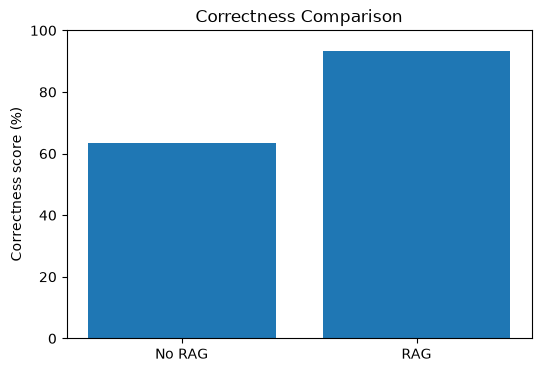

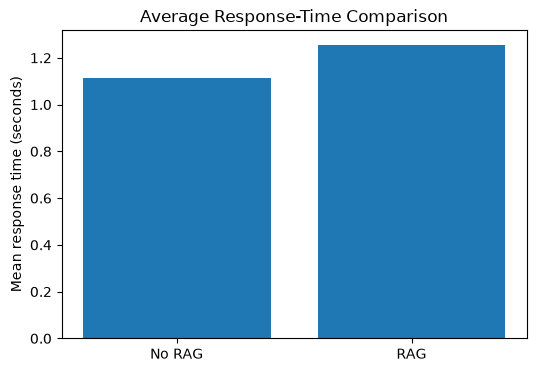

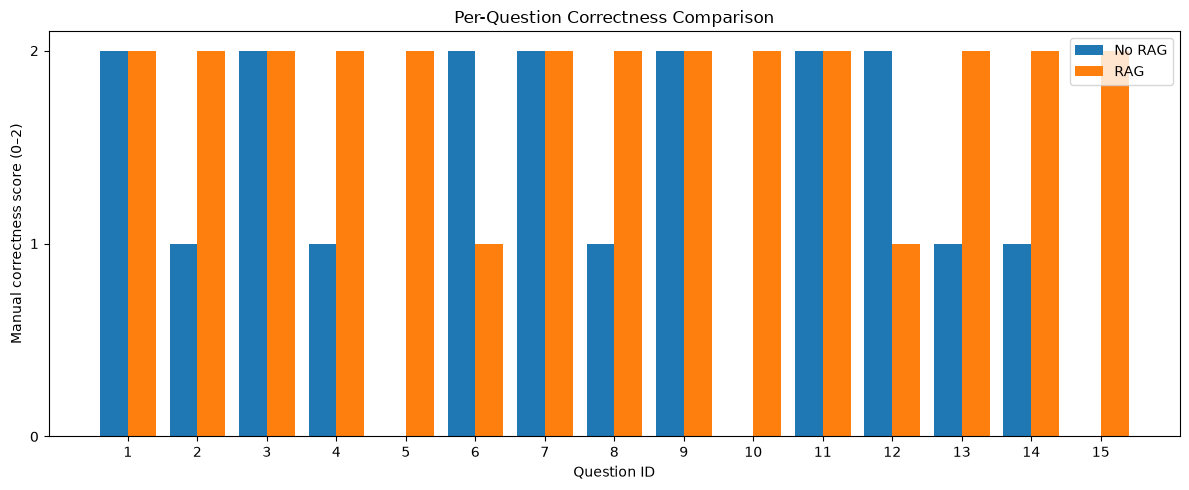

In [24]:
if metrics is not None:
    plt.figure(figsize=(6, 4))
    plt.bar(["No RAG", "RAG"], [metrics["no_rag_correctness_pct"], metrics["rag_correctness_pct"]])
    plt.title("Correctness Comparison")
    plt.ylabel("Correctness score (%)")
    plt.ylim(0, 100)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.bar(["No RAG", "RAG"], [metrics["no_rag_response"]["mean"], metrics["rag_response"]["mean"]])
    plt.title("Average Response-Time Comparison")
    plt.ylabel("Mean response time (seconds)")
    plt.show()

    plot_frame = review_df.sort_values("question_id")
    positions = np.arange(len(plot_frame))
    width = 0.4
    plt.figure(figsize=(12, 5))
    plt.bar(positions - width / 2, plot_frame["no_rag_correctness"], width, label="No RAG")
    plt.bar(positions + width / 2, plot_frame["rag_correctness"], width, label="RAG")
    plt.title("Per-Question Correctness Comparison")
    plt.xlabel("Question ID")
    plt.ylabel("Manual correctness score (0–2)")
    plt.xticks(positions, plot_frame["question_id"])
    plt.yticks([0, 1, 2])
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Complete manual scoring to create charts.")

## 18. Failure Analysis

These tables isolate common failure modes after scoring. “Low groundedness” means a score below 1.0. The slowest table treats each condition response as a separate timed observation.

In [25]:
if metrics is not None:
    analysis = review_df.copy()
    answerable = _to_bool(analysis["expected_answerable"])
    rag_lower = analysis[analysis["rag_correctness"] < analysis["no_rag_correctness"]]
    retrieval_failed = analysis[answerable & (analysis["retrieval_hit"] == 0)]
    low_groundedness = analysis[analysis["rag_groundedness"] < 1.0]
    hallucinated_unanswerable = analysis[(~answerable) & (analysis["hallucination_handling"] == 0)]
    slowest = pd.concat([
        analysis[["question_id", "question", "no_rag_response_seconds"]]
        .rename(columns={"no_rag_response_seconds": "response_seconds"})
        .assign(condition="No RAG"),
        analysis[["question_id", "question", "rag_response_seconds"]]
        .rename(columns={"rag_response_seconds": "response_seconds"})
        .assign(condition="RAG"),
    ]).sort_values("response_seconds", ascending=False).head(5)

    print("RAG scored lower than no-RAG")
    display(rag_lower[["question_id", "question", "no_rag_correctness", "rag_correctness", "review_notes"]])
    print("Retrieval failed on answerable questions")
    display(retrieval_failed[["question_id", "question", "retrieved_chunk_ids", "rag_correctness", "review_notes"]])
    print("Low-groundedness RAG answers")
    display(low_groundedness[["question_id", "question", "rag_answer", "rag_groundedness", "review_notes"]])
    print("Unanswerable questions where the model hallucinated")
    display(hallucinated_unanswerable[["question_id", "question", "rag_answer", "hallucination_handling", "review_notes"]])
    print("Slowest responses")
    display(slowest[["question_id", "question", "condition", "response_seconds"]])
else:
    print("Complete manual scoring to run failure analysis.")

RAG scored lower than no-RAG


,question_id,question,no_rag_correctness,rag_correctness,review_notes
5,6,What is the difference between an item or enti...,2,1,RAG gives the correct distinction but incorrec...
11,12,Why might an organization transform unstructur...,2,1,RAG gives the main reason but overstates that ...


Retrieval failed on answerable questions


,question_id,question,retrieved_chunk_ids,rag_correctness,review_notes


Low-groundedness RAG answers


,question_id,question,rag_answer,rag_groundedness,review_notes
5,6,What is the difference between an item or enti...,The difference between an item or entity and a...,0.5,RAG gives the correct distinction but incorrec...
11,12,Why might an organization transform unstructur...,An organization might transform unstructured d...,0.5,RAG gives the main reason but overstates that ...


Unanswerable questions where the model hallucinated


,question_id,question,rag_answer,hallucination_handling,review_notes


Slowest responses


,question_id,question,condition,response_seconds
0,1,What is the difference between a datum and data?,No RAG,1.965726
2,3,What is the difference between structured and ...,RAG,1.881132
5,6,What is the difference between an item or enti...,RAG,1.689189
3,4,What characteristics make a dataset structured?,No RAG,1.447949
3,4,What characteristics make a dataset structured?,RAG,1.436482


## 19. Discussion Prompts

Complete these prompts after manual scoring:

- Did RAG improve correctness?
- Did retrieval failures lead to incorrect answers?
- Did the small model follow the instruction to avoid unsupported claims?
- Which question types were most difficult?
- Was the response time reasonable for a low-resource local deployment?
- What limitations resulted from the small dataset?
- What preprocessing issues affected retrieval?

## 20. Report-Ready Summary

This summary uses calculated metrics only. It does not assert statistical significance or causal generalization from the small baseline.

In [26]:
def build_report_summary(metrics: dict) -> str:
    """Build a conservative report paragraph from calculated baseline metrics."""
    required = {
        "number_evaluated", "no_rag_correctness_pct", "rag_correctness_pct",
        "retrieval_hit_rate_at_3", "average_groundedness",
        "hallucination_handling_rate", "no_rag_response", "rag_response",
    }
    missing = required - set(metrics)
    if missing:
        raise ValueError(f"Metrics dictionary is missing: {sorted(missing)}")
    return (
        f"This small initial Archivist baseline evaluated {metrics['number_evaluated']} questions "
        f"using manual scoring. No-RAG answers achieved {metrics['no_rag_correctness_pct']:.1f}% of "
        f"the maximum correctness score, compared with {metrics['rag_correctness_pct']:.1f}% for RAG. "
        f"Retrieval Hit Rate@3 was {metrics['retrieval_hit_rate_at_3']:.1%}, and average RAG "
        f"groundedness was {metrics['average_groundedness']:.2f} on a 0–1 scale. On the questions "
        f"marked unanswerable from the section, hallucination handling was "
        f"{metrics['hallucination_handling_rate']:.1%}. Mean response time was "
        f"{metrics['no_rag_response']['mean']:.2f} seconds without RAG and "
        f"{metrics['rag_response']['mean']:.2f} seconds with RAG, showing the observed local "
        f"response-time tradeoff. These measurements describe only this small question set, source "
        f"text, manual rubric, models, and hardware; they do not establish statistical significance "
        f"or performance in a production Archivist deployment."
    )


if metrics is not None:
    report_summary = build_report_summary(metrics)
    report_path = Path(RESULTS_PATH).parent / "report_summary.txt"
    report_path.write_text(report_summary, encoding="utf-8")
    print(report_summary)
    print(f"\nSaved report-ready summary to {report_path}")
else:
    print("Report summary not created: complete and validate manual scoring first.")

This small initial Archivist baseline evaluated 15 questions using manual scoring. No-RAG answers achieved 63.3% of the maximum correctness score, compared with 93.3% for RAG. Retrieval Hit Rate@3 was 100.0%, and average RAG groundedness was 0.93 on a 0–1 scale. On the questions marked unanswerable from the section, hallucination handling was 100.0%. Mean response time was 1.11 seconds without RAG and 1.25 seconds with RAG, showing the observed local response-time tradeoff. These measurements describe only this small question set, source text, manual rubric, models, and hardware; they do not establish statistical significance or performance in a production Archivist deployment.

Saved report-ready summary to results/report_summary.txt


## 21. Potential Improvements

Future work could evaluate:

- improved PDF or HTML preprocessing that removes navigation, repeated headers, and extraction artifacts;
- token-aware chunking and experiments with different chunk sizes and overlap;
- larger top-k values, metadata-based filtering, and a reranking stage;
- stronger local chat models and alternative local embedding models;
- larger, independently authored question sets and independent human evaluators;
- automated RAG evaluation with RAGAS as a supplement to, not a replacement for, human review;
- Docker-based monitoring that can observe both the notebook and Ollama runtime memory; and
- integration of the validated retrieval and generation components into the Archivist application.